# Customer Purchase Prediction from E-Commerce

We will predict whether an e-commerce customer is likely to make a purchase using four classification models:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest

This notebook follows the complete ML workflow from data understanding and EDA to model comparison and final prediction.

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [4]:
df = pd.read_csv("/content/customer_purchase_data.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1500, 9)


In [5]:
print(df.head())

   Age  Gender   AnnualIncome  NumberOfPurchases  ProductCategory  \
0   40       1   66120.267939                  8                0   
1   20       1   23579.773583                  4                2   
2   27       1  127821.306432                 11                2   
3   24       1  137798.623120                 19                3   
4   31       1   99300.964220                 19                1   

   TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  PurchaseStatus  
0           30.568601               0                 5               1  
1           38.240097               0                 5               0  
2           31.633212               1                 0               1  
3           46.167059               0                 4               1  
4           19.823592               0                 0               1  


## 3. Data Understanding

In [6]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types and non-null values:")
df.info()

Dataset shape: (1500, 9)

Columns:
['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory', 'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed', 'PurchaseStatus']

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


In [7]:
print("Statistical summary:")
display(df.describe())

Statistical summary:


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


In [8]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nPurchase status:")
print(df["PurchaseStatus"].value_counts())

Missing values:
Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64

Duplicate rows: 112

Purchase status:
PurchaseStatus
0    852
1    648
Name: count, dtype: int64


### What we found

- `PurchaseStatus` is the target variable.
- `0` means no purchase and `1` means purchase.
- The dataset contains customer and website-behavior features.
- Duplicate rows are removed before model training.

## 4. Data Cleaning & Preprocessing

In [9]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print("Rows before cleaning :", before)
print("Rows after cleaning  :", after)
print("Duplicates removed   :", before - after)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Rows before cleaning : 1500
Rows after cleaning  : 1388
Duplicates removed   : 112

Missing values after cleaning:
Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64


In [10]:
X = df.drop("PurchaseStatus", axis=1)
y = df["PurchaseStatus"]

print("Features:", X.columns.tolist())
print("Target: PurchaseStatus")

Features: ['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory', 'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed']
Target: PurchaseStatus


The supplied dataset is already numerically encoded, so additional categorical encoding is not required.

We scale the features for **Logistic Regression and KNN** because both are affected by feature scale. Decision Tree and Random Forest do not need scaling.

## 5. Exploratory Data Analysis

### Graph 1 — Purchase Status

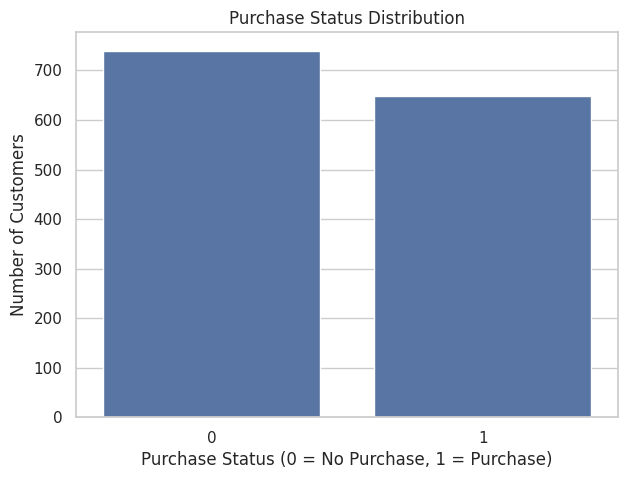

Insight: This shows the number of customers who purchased and did not purchase.


In [11]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="PurchaseStatus")
plt.title("Purchase Status Distribution")
plt.xlabel("Purchase Status (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Number of Customers")
plt.show()

print("Insight: This shows the number of customers who purchased and did not purchase.")

### Graph 2 — Age Distribution

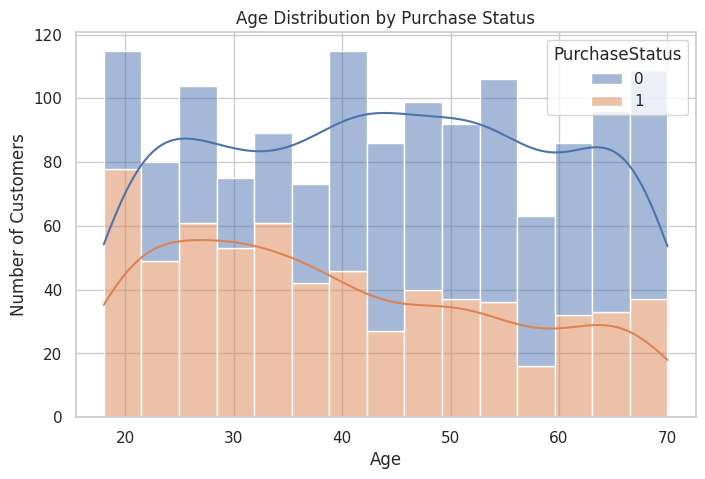

Insight: This helps us see how purchase behavior is distributed across age groups.


In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="PurchaseStatus",
             bins=15, kde=True, multiple="stack")
plt.title("Age Distribution by Purchase Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

print("Insight: This helps us see how purchase behavior is distributed across age groups.")

### Graph 3 — Annual Income

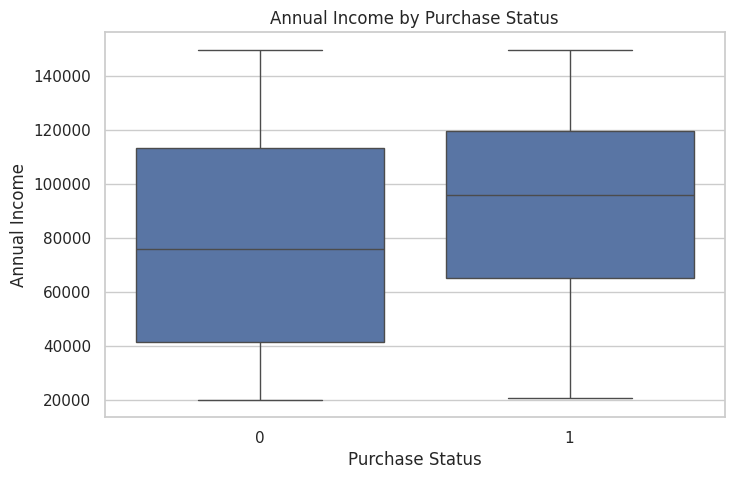

Insight: This compares income levels of purchasing and non-purchasing customers.


In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="PurchaseStatus", y="AnnualIncome")
plt.title("Annual Income by Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Annual Income")
plt.show()

print("Insight: This compares income levels of purchasing and non-purchasing customers.")

### Graph 4 — Website Time

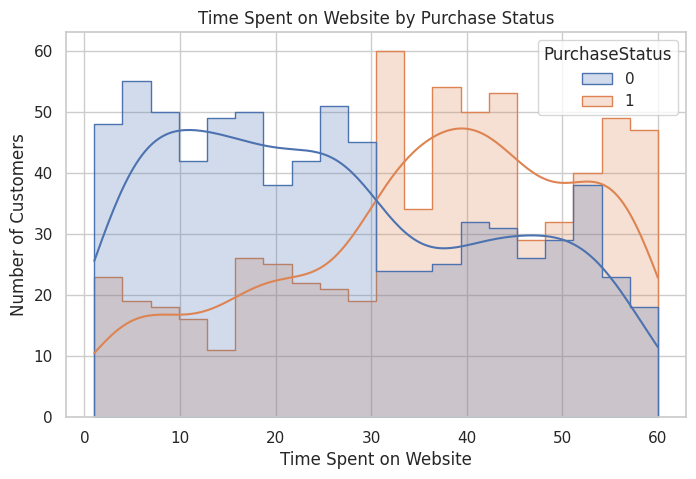

Insight: This shows whether website engagement differs between the two purchase groups.


In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="TimeSpentOnWebsite",
             hue="PurchaseStatus", bins=20, kde=True, element="step")
plt.title("Time Spent on Website by Purchase Status")
plt.xlabel("Time Spent on Website")
plt.ylabel("Number of Customers")
plt.show()

print("Insight: This shows whether website engagement differs between the two purchase groups.")

### Graph 5 — Loyalty Program

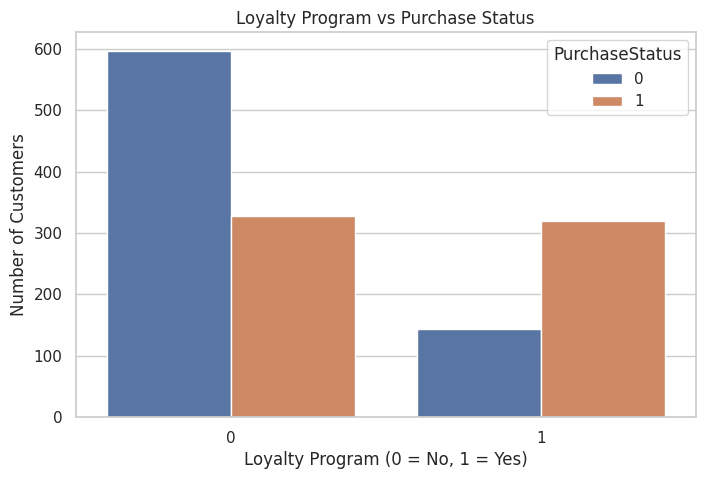

Insight: We can compare purchase behavior of loyalty-program members and non-members.


In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="LoyaltyProgram", hue="PurchaseStatus")
plt.title("Loyalty Program vs Purchase Status")
plt.xlabel("Loyalty Program (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

print("Insight: We can compare purchase behavior of loyalty-program members and non-members.")

### Graph 6 — Correlation Heatmap

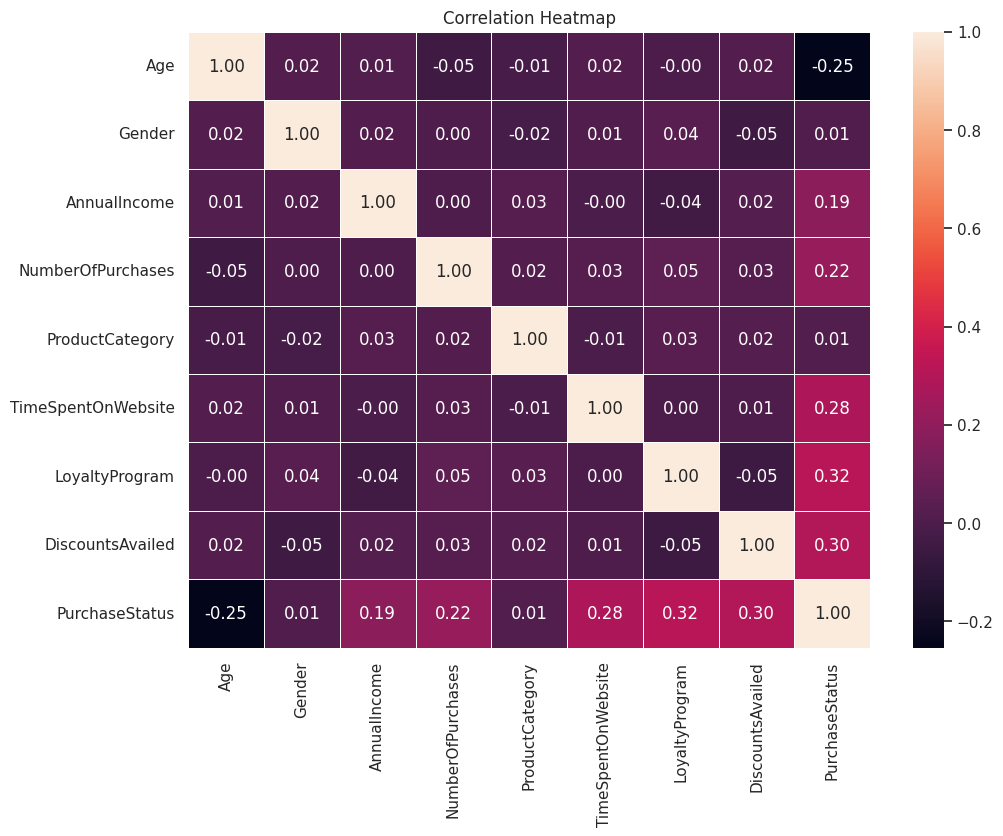

Correlation with PurchaseStatus:


,PurchaseStatus
PurchaseStatus,1.000000
LoyaltyProgram,0.318059
DiscountsAvailed,0.296606
TimeSpentOnWebsite,0.282127
NumberOfPurchases,0.219116
AnnualIncome,0.191218
ProductCategory,0.014349
Gender,0.008856
Age,-0.253598


In [16]:
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

print("Correlation with PurchaseStatus:")
display(corr["PurchaseStatus"].sort_values(ascending=False))

### Graph 7 — Previous Purchases

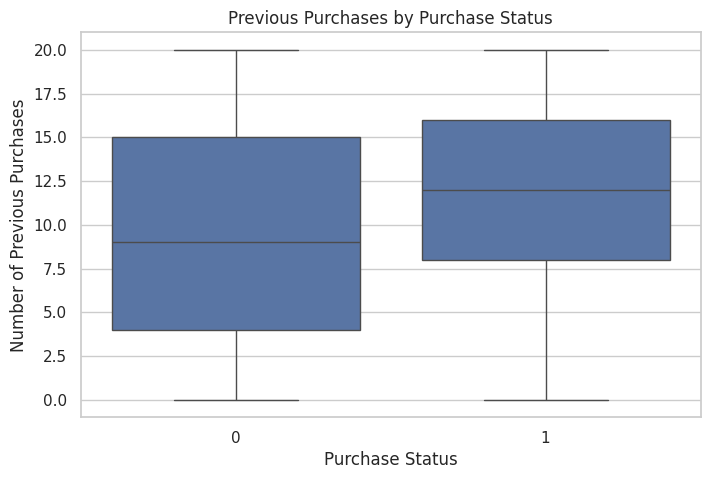

Insight: This compares previous purchase activity between the two groups.


In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="PurchaseStatus", y="NumberOfPurchases")
plt.title("Previous Purchases by Purchase Status")
plt.xlabel("Purchase Status")
plt.ylabel("Number of Previous Purchases")
plt.show()

print("Insight: This compares previous purchase activity between the two groups.")

## 6. Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Number of features:", X_train.shape[1])

Training samples: 1110
Testing samples : 278
Number of features: 8


We use an **80:20 split**. `stratify=y` keeps the purchase/no-purchase proportion similar in both sets.

## 7. Logistic Regression

In [19]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression trained and predictions generated.")

Logistic Regression trained and predictions generated.


Accuracy: 0.8309
Precision: 0.8168
Recall: 0.8231
F1-Score: 0.8199


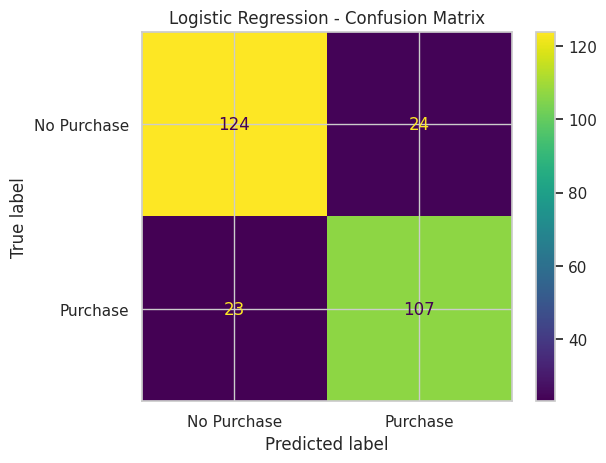

In [20]:
lr_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall": recall_score(y_test, y_pred_lr, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_lr, zero_division=0)
}

for metric, value in lr_metrics.items():
    print(f"{metric}: {value:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["No Purchase", "Purchase"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

**Simple idea:** Logistic Regression gives us a strong and easy-to-understand baseline for the purchase prediction problem.

 ## 8. Decision Tree  

In [21]:
decision_tree_model = DecisionTreeClassifier(
    criterion="gini", max_depth=5, random_state=42
)

decision_tree_model.fit(X_train, y_train)
y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree trained and predictions generated.")

Decision Tree trained and predictions generated.


Accuracy: 0.8525
Precision: 0.8201
Recall: 0.8769
F1-Score: 0.8476


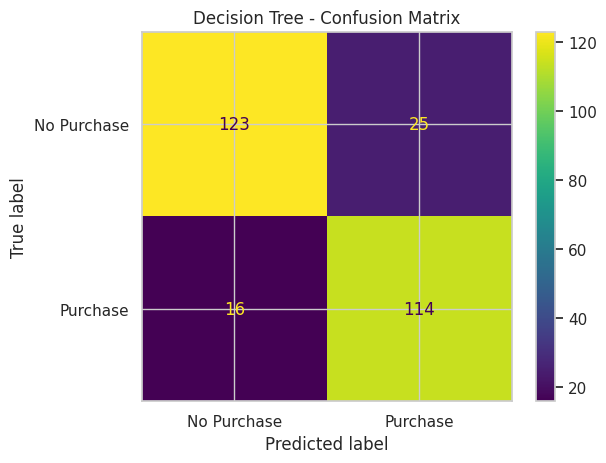

In [22]:
dt_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt, zero_division=0),
    "Recall": recall_score(y_test, y_pred_dt, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_dt, zero_division=0)
}

for metric, value in dt_metrics.items():
    print(f"{metric}: {value:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=["No Purchase", "Purchase"]
)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

**Simple idea:** The Decision Tree learns a set of if/else-style rules. We limit its depth to 5 to keep the tree from becoming unnecessarily complex.

## 9. K-Nearest Neighbors (KNN)

In [23]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN trained and predictions generated.")

KNN trained and predictions generated.


Accuracy: 0.8525
Precision: 0.8112
Recall: 0.8923
F1-Score: 0.8498


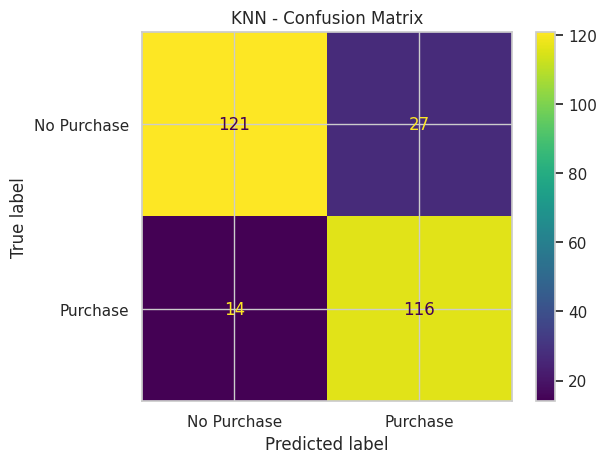

In [24]:
knn_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn, zero_division=0),
    "Recall": recall_score(y_test, y_pred_knn, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_knn, zero_division=0)
}

for metric, value in knn_metrics.items():
    print(f"{metric}: {value:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=["No Purchase", "Purchase"]
)
plt.title("KNN - Confusion Matrix")
plt.show()

In [25]:
dt_importance = pd.Series(
    decision_tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top Decision Tree features:")
display(dt_importance)

Top Decision Tree features:


,0
TimeSpentOnWebsite,0.217957
LoyaltyProgram,0.177711
DiscountsAvailed,0.170732
AnnualIncome,0.167449
Age,0.146449
NumberOfPurchases,0.119011
ProductCategory,0.000691
Gender,0.000000


**Simple idea:** KNN looks at the five most similar customers and uses their classes to decide whether the new customer is likely to purchase. Scaling is important because KNN uses distance between observations.

## 10. Random Forest

In [26]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest trained and predictions generated.")

Random Forest trained and predictions generated.


Accuracy: 0.9281
Precision: 0.9297
Recall: 0.9154
F1-Score: 0.9225


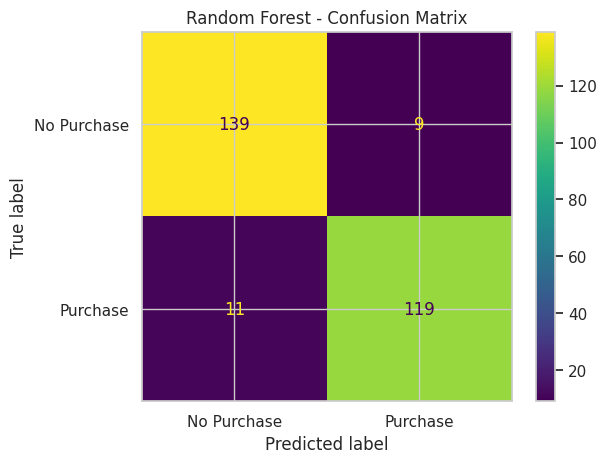

In [27]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_rf, zero_division=0)
}

for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["No Purchase", "Purchase"]
)
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [28]:
rf_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top Random Forest features:")
display(rf_importance)

Top Random Forest features:


,0
TimeSpentOnWebsite,0.200957
Age,0.176105
AnnualIncome,0.165712
DiscountsAvailed,0.144991
NumberOfPurchases,0.138214
LoyaltyProgram,0.122819
ProductCategory,0.035967
Gender,0.015235


**Simple idea:** Random Forest combines many Decision Trees, which usually gives a more stable prediction than relying on one tree.

## 11. Model Comparison

In [29]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [
        lr_metrics["Accuracy"], knn_metrics["Accuracy"],
        dt_metrics["Accuracy"], rf_metrics["Accuracy"]
    ],
    "Precision": [
        lr_metrics["Precision"], knn_metrics["Precision"],
        dt_metrics["Precision"], rf_metrics["Precision"]
    ],
    "Recall": [
        lr_metrics["Recall"], knn_metrics["Recall"],
        dt_metrics["Recall"], rf_metrics["Recall"]
    ],
    "F1-Score": [
        lr_metrics["F1-Score"], knn_metrics["F1-Score"],
        dt_metrics["F1-Score"], rf_metrics["F1-Score"]
    ]
})

comparison = comparison.sort_values(
    by="F1-Score", ascending=False
).reset_index(drop=True)

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9281,0.9297,0.9154,0.9225
1,KNN,0.8525,0.8112,0.8923,0.8498
2,Decision Tree,0.8525,0.8201,0.8769,0.8476
3,Logistic Regression,0.8309,0.8168,0.8231,0.8199


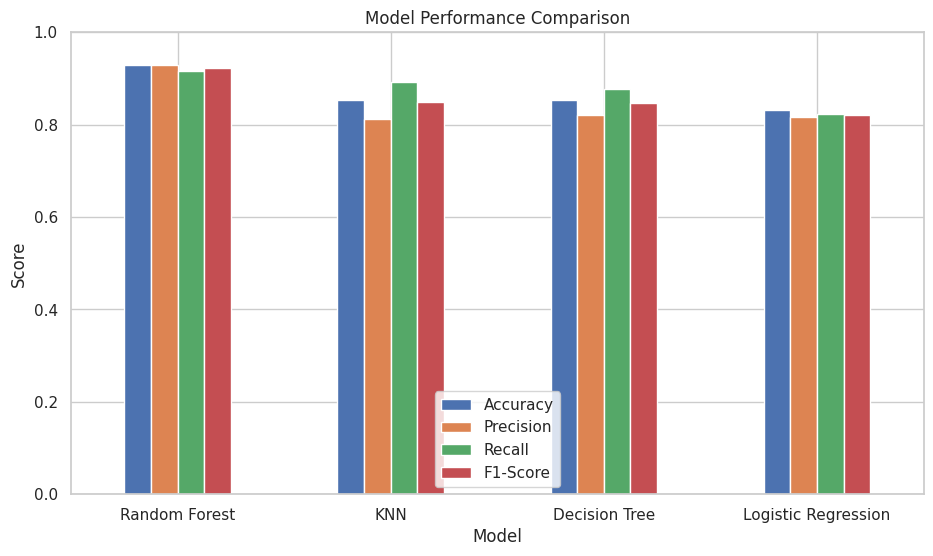

In [30]:
comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(kind="bar", figsize=(11, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

We compare all four models using the same metrics. The **F1-score** is used to choose the final model because it balances precision and recall.

## 12. Best Model

In [31]:
model_objects = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

best_model_name = comparison.loc[0, "Model"]
best_model = model_objects[best_model_name]

print("Best Model:", best_model_name)
print("Best F1-Score:", f"{comparison.loc[0, 'F1-Score']:.4f}")

Best Model: Random Forest
Best F1-Score: 0.9225


## 13. Final Prediction

In [32]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Gender": [1],
    "AnnualIncome": [80000],
    "NumberOfPurchases": [10],
    "ProductCategory": [2],
    "TimeSpentOnWebsite": [35],
    "LoyaltyProgram": [1],
    "DiscountsAvailed": [3]
})

prediction = best_model.predict(new_customer)[0]
probability = best_model.predict_proba(new_customer)[0][1]

print(
    "Prediction:",
    "Customer Will Purchase" if prediction == 1
    else "Customer Will Not Purchase"
)
print(f"Purchase probability: {probability:.2%}")

Prediction: Customer Will Purchase
Purchase probability: 97.28%


## 14. Conclusion

In [33]:
print("Project completed successfully.")
print(f"Best model: {best_model_name}")
print(
    "The selected model can help an e-commerce platform identify "
    "customers who are more likely to make a purchase."
)
print(
    "Future improvements could include hyperparameter tuning, "
    "cross-validation, more customer-behavior features and a larger dataset."
)

Project completed successfully.
Best model: Random Forest
The selected model can help an e-commerce platform identify customers who are more likely to make a purchase.
Future improvements could include hyperparameter tuning, cross-validation, more customer-behavior features and a larger dataset.
